<a href="https://colab.research.google.com/github/Jeeshau/material-intelligence-engine/blob/main/material_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Phase 1

Designed a relational database schema and ingested 174 real project material records from Notion into SQLite, with automated data cleaning for price normalization and null handling

In [2]:
# Cell 1 — 连接 Google Drive，自动读取所有 CSV
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os
import glob

# Google Drive 数据文件夹（正确路径）
DATA_DIR = '/content/drive/MyDrive/material-engine/data'

# 自动找到所有 CSV 文件
csv_files = glob.glob(f'{DATA_DIR}/*.csv')
print(f"找到 {len(csv_files)} 个 CSV 文件：")
for f in csv_files:
    print(f"  - {os.path.basename(f)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
找到 2 个 CSV 文件：
  - Alidoro Master Database 2df80731963d8130bd80ec263c81fd82_all.csv
  - GOODVETS - ALL LOCATIONS - FFE 2023 - 540 HUDSON.csv


In [4]:
# Cell 2 — 读取并预览数据
import pandas as pd

notion_df = pd.read_csv(f'{DATA_DIR}/Alidoro Master Database 2df80731963d8130bd80ec263c81fd82_all.csv')
google_df = pd.read_csv(f'{DATA_DIR}/GOODVETS - ALL LOCATIONS - FFE 2023 - 540 HUDSON.csv', skiprows=5, header=1)

print("=== Notion 数据 ===")
print(f"行数: {len(notion_df)}, 列数: {len(notion_df.columns)}")
print(notion_df[['Name', 'Category (Designer Use)', 'Manufacturer', 'Unit Cost', 'Lead Time', 'Order Status']].head(5))

print("\n=== Google Sheet 数据 ===")
print(f"行数: {len(google_df)}, 列数: {len(google_df.columns)}")
print(google_df.head(3))

=== Notion 数据 ===
行数: 174, 列数: 47
                    Name Category (Designer Use)   Manufacturer   Unit Cost  \
0               Recessed        Lighting Fixture           Lusa     $80.10    
1  Quarry Tile Cove Base                  Finish        Tilebar      $0.00    
2                  Stool               Furniture  Anthropologie    $358.20    
3           Zellige Tile                  Finish       Zia Tile  $2,983.28    
4                 Toilet        Plumbing Fixture            NaN         NaN   

           Lead Time  Order Status  
0  3-5 Business Days      ESTIMATE  
1           In Stock     UPDATE PO  
2                NaN  NOT IN SCOPE  
3           In Stock     UPDATE PO  
4                NaN  NOT IN SCOPE  

=== Google Sheet 数据 ===
行数: 66, 列数: 16
                                          Unnamed: 0  PT-01  \
0                                                NaN  PT-02   
1  FOR DOORS I'D\nGO WITH LACQUER\nOR LAMINATE\nF...  PT-03   
2                                       

In [5]:
# Cell 3 — 清洗 Notion 数据 + 导入 SQLite

import sqlite3
import pandas as pd
import re

# 1. 选取核心列
notion_clean = notion_df[[
    'Name', 'Category (Designer Use)', 'Manufacturer', 'Model',
    'Description', 'Finish / Color', 'Product Size', 'Unit',
    'Unit Cost', 'Lead Time', 'Order Status', 'Approval Status',
    'TAG', 'Link', 'Location', 'NOTES'
]].copy()

# 2. 重命名列（去掉空格和括号，SQL友好）
notion_clean.columns = [
    'name', 'category', 'manufacturer', 'model',
    'description', 'finish_color', 'product_size', 'unit',
    'unit_cost', 'lead_time', 'order_status', 'approval_status',
    'tag', 'link', 'location', 'notes'
]

# 3. 清洗 unit_cost：把 "$1,121.40" 变成数字 1121.40
def clean_price(val):
    if pd.isna(val):
        return None
    cleaned = re.sub(r'[$,]', '', str(val)).strip()
    try:
        return float(cleaned)
    except:
        return None

notion_clean['unit_cost'] = notion_clean['unit_cost'].apply(clean_price)

# 4. 清洗空白字符串
notion_clean = notion_clean.replace('', None)
notion_clean['name'] = notion_clean['name'].str.strip()
notion_clean['category'] = notion_clean['category'].str.strip()

# 5. 加项目来源标记
notion_clean['source'] = 'Notion'
notion_clean['project'] = 'Alidoro ESB'

# 6. 导入 SQLite
conn = sqlite3.connect('materials.db')
notion_clean.to_sql('materials', conn, if_exists='replace', index=True, index_label='id')
conn.close()

print(f"✅ 成功导入 {len(notion_clean)} 条材料数据")
print("\n预览清洗后的数据：")
print(notion_clean[['name', 'category', 'manufacturer', 'unit_cost', 'order_status']].head(8).to_string())


✅ 成功导入 174 条材料数据

预览清洗后的数据：
                        name          category             manufacturer  unit_cost  order_status
0                   Recessed  Lighting Fixture                     Lusa      80.10      ESTIMATE
1      Quarry Tile Cove Base            Finish                  Tilebar       0.00     UPDATE PO
2                      Stool         Furniture            Anthropologie     358.20  NOT IN SCOPE
3               Zellige Tile            Finish                 Zia Tile    2983.28     UPDATE PO
4                     Toilet  Plumbing Fixture                      NaN        NaN  NOT IN SCOPE
5                    Troffer  Lighting Fixture                    TOPAZ      32.13      ESTIMATE
6  Track Head\nSurface Mount  Lighting Fixture  Etsy_\nSmile Lamp Works     169.00      ESTIMATE
7   Eliason - Single Traffic              Door                      NaN    2700.00      ESTIMATE


In [6]:
# Cell 4 — 你的第一批 SQL 查询

import sqlite3
import pandas as pd

conn = sqlite3.connect('materials.db')

# 查询 1: 所有材料类别有哪些？
print("=== 材料类别分布 ===")
q1 = pd.read_sql_query("""
    SELECT category, COUNT(*) as 数量
    FROM materials
    WHERE category IS NOT NULL
    GROUP BY category
    ORDER BY 数量 DESC
""", conn)
print(q1.to_string())

# 查询 2: 所有 Lighting Fixture，按价格排序
print("\n=== Lighting Fixtures (按价格) ===")
q2 = pd.read_sql_query("""
    SELECT name, manufacturer, unit_cost, order_status
    FROM materials
    WHERE category = 'Lighting Fixture'
    AND unit_cost IS NOT NULL
    ORDER BY unit_cost DESC
""", conn)
print(q2.to_string())

# 查询 3: 还没有下单的材料 (ESTIMATE状态)
print("\n=== 待确认材料 (ESTIMATE) ===")
q3 = pd.read_sql_query("""
    SELECT name, category, manufacturer, unit_cost
    FROM materials
    WHERE order_status = 'ESTIMATE'
    AND unit_cost IS NOT NULL
    ORDER BY unit_cost DESC
    LIMIT 10
""", conn)
print(q3.to_string())

conn.close()

=== 材料类别分布 ===
                category  数量
0       Millwork Catalog  88
1                 Finish  34
2               Hardware  25
3       Lighting Fixture  16
4              Furniture   4
5                   Door   2
6       Plumbing Fixture   1
7  Drafting Place Holder   1

=== Lighting Fixtures (按价格) ===
                         name                 manufacturer  unit_cost order_status
0              Custom Pendant                       Custom    2500.00     ESTIMATE
1                 Wall Sconce                   Slow Roads     378.00     ESTIMATE
2              Linear Pendant  Etsy_\nNew Wine Old Bottles     375.00     ESTIMATE
3   Track Head\nSurface Mount      Etsy_\nSmile Lamp Works     169.00     ESTIMATE
4                         LED                   ASPECT LED     156.50     ESTIMATE
5                     Pendant               Ideas4Lighting     116.37     ESTIMATE
6               New Exit Sign                       AtLite     100.00     ESTIMATE
7                    Recess

## Phase 2 — ETL Pipeline

Built an ETL pipeline ingesting material data from two sources (Notion API export + Google Sheets), normalizing heterogeneous schemas into a unified SQLite database across 227 records from 2 real interior design projects

In [8]:
# Cell 5 — 清洗 Google Sheet 数据 + 合并进数据库

import sqlite3
import pandas as pd
import re

# 重新读取 Google Sheet，找到真正的数据行
raw = pd.read_csv(f'{DATA_DIR}/GOODVETS - ALL LOCATIONS - FFE 2023 - 540 HUDSON.csv', header=None)

# 找到包含 TAG 列的那一行作为 header
header_row = None
for i, row in raw.iterrows():
    if any(str(v).strip().upper() in ['TAG', 'PT-01', 'ITEM']
           for v in row.values if pd.notna(v)):
        header_row = i
        break

print(f"Header 在第 {header_row} 行")
print(raw.iloc[header_row].tolist())

Header 在第 5 行
['STATUS', 'TAG', 'AREA', 'IMAGE', 'ITEM DESCRIPTION', 'Qty. (10%)', nan, 'UNIT PRICE', 'CUSTOMIZATION CHARGE', 'SHIPPING / PACKING', 'TAX', 'TOTAL PRICE \n(SHIP&TAX)', 'LEAD TIME', 'WEBSITE', 'SPEC', 'CONTACT INFO']


In [10]:
# Cell 6 — 清洗 Google Sheet + 合并进数据库

import sqlite3
import pandas as pd
import re

# 用第5行作为 header 重新读取
gs_df = pd.read_csv(f'{DATA_DIR}/GOODVETS - ALL LOCATIONS - FFE 2023 - 540 HUDSON.csv',
                    skiprows=5, header=0)

print("原始列名:", gs_df.columns.tolist())
print(f"行数: {len(gs_df)}")
print(gs_df.head(3).to_string())

原始列名: ['STATUS', 'TAG', 'AREA', 'IMAGE', 'ITEM DESCRIPTION', 'Qty. (10%)', 'Unnamed: 6', 'UNIT PRICE', 'CUSTOMIZATION CHARGE', 'SHIPPING / PACKING', 'TAX', 'TOTAL PRICE \n(SHIP&TAX)', 'LEAD TIME', 'WEBSITE', 'SPEC', 'CONTACT INFO']
行数: 67
                                                                                                 STATUS    TAG            AREA  IMAGE                                                                                                              ITEM DESCRIPTION  Qty. (10%) Unnamed: 6 UNIT PRICE  CUSTOMIZATION CHARGE SHIPPING / PACKING    TAX TOTAL PRICE \n(SHIP&TAX)                      LEAD TIME WEBSITE SPEC CONTACT INFO
0                                                                                                   NaN  PT-01     WALLS\nTYP.    NaN                                          INTERIOR / Eggshell Finish\nBENJAMIN MOORE WHITE OC-151\nSTANDARD, COMMERCIAL, GRADE         NaN     GALLON     $82.99                   NaN                NaN  $

In [11]:
# Cell 7 — 完整清洗 Google Sheet + 合并入数据库

def clean_price(val):
    if pd.isna(val): return None
    cleaned = re.sub(r'[$,]', '', str(val)).strip()
    try: return float(cleaned)
    except: return None

# 选取有用的列
gs_clean = gs_df[[
    'STATUS', 'TAG', 'AREA', 'ITEM DESCRIPTION',
    'UNIT PRICE', 'Qty. (10%)', 'SHIPPING / PACKING'
]].copy()

# 重命名对齐 Notion 的格式
gs_clean.columns = [
    'order_status', 'tag', 'location', 'name',
    'unit_cost', 'unit', 'notes'
]

# 清洗
gs_clean['unit_cost'] = gs_clean['unit_cost'].apply(clean_price)
gs_clean['name'] = gs_clean['name'].str.replace(r'\n', ' ', regex=True).str.strip()
gs_clean['location'] = gs_clean['location'].str.replace(r'\n', ' ', regex=True).str.strip()

# 补充空列（Notion有但Google Sheet没有的）
gs_clean['category'] = None
gs_clean['manufacturer'] = None
gs_clean['model'] = None
gs_clean['description'] = gs_clean['name']
gs_clean['finish_color'] = None
gs_clean['product_size'] = None
gs_clean['lead_time'] = None
gs_clean['approval_status'] = gs_clean['order_status']
gs_clean['link'] = None
gs_clean['source'] = 'Google Sheet'
gs_clean['project'] = 'Goodvets 540 Hudson'

# 去掉 name 为空的行
gs_clean = gs_clean.dropna(subset=['name'])
gs_clean = gs_clean[gs_clean['name'].str.len() > 2]

# 合并进数据库
conn = sqlite3.connect('materials.db')
gs_clean.to_sql('materials', conn, if_exists='append', index=True, index_label='id')

# 验证合并结果
total = pd.read_sql_query("SELECT COUNT(*) as total FROM materials", conn)
by_project = pd.read_sql_query("""
    SELECT project, COUNT(*) as 数量
    FROM materials
    GROUP BY project
""", conn)
conn.close()

print(f"✅ Google Sheet 导入 {len(gs_clean)} 条")
print(f"\n=== 数据库总览 ===")
print(total.to_string())
print("\n=== 按项目分布 ===")
print(by_project.to_string())

✅ Google Sheet 导入 53 条

=== 数据库总览 ===
   total
0    227

=== 按项目分布 ===
               project   数量
0          Alidoro ESB  174
1  Goodvets 540 Hudson   53


## Read the cleaned files

In [12]:
# 导出为 CSV 方便审阅
import sqlite3
import pandas as pd

conn = sqlite3.connect('materials.db')
df = pd.read_sql_query("SELECT * FROM materials", conn)
conn.close()

df.to_csv('materials_export.csv', index=False)
print("✅ 导出完成")

# 下载到本地
from google.colab import files
files.download('materials_export.csv')

✅ 导出完成


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Add Image to each material

In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('materials.db')
df = pd.read_sql_query("SELECT name, category, link, project FROM materials", conn)
conn.close()

total = len(df)
has_link = df['link'].notna().sum()
print(f"总记录: {total}")
print(f"有链接: {has_link} ({has_link/total*100:.1f}%)")
print(f"无链接: {total - has_link}")
print(f"\n有链接的来源域名:")
print(df['link'].dropna().str.extract(r'https?://([^/]+)')[0].value_counts().head(10))

总记录: 227
有链接: 99 (43.6%)
无链接: 128

有链接的来源域名:
0
www.amazon.com                        19
ziatile.com                           10
www.bairdbrothers.com                  8
www.tilebar.com                        4
www.ikea.com                           4
www.homedepot.com                      4
www.grayglass.net                      3
www.ceilume.com                        3
www.antiquemirror.it                   3
www.borrowedearthcollaborative.com     3
Name: count, dtype: int64


✅ Zellige Tile


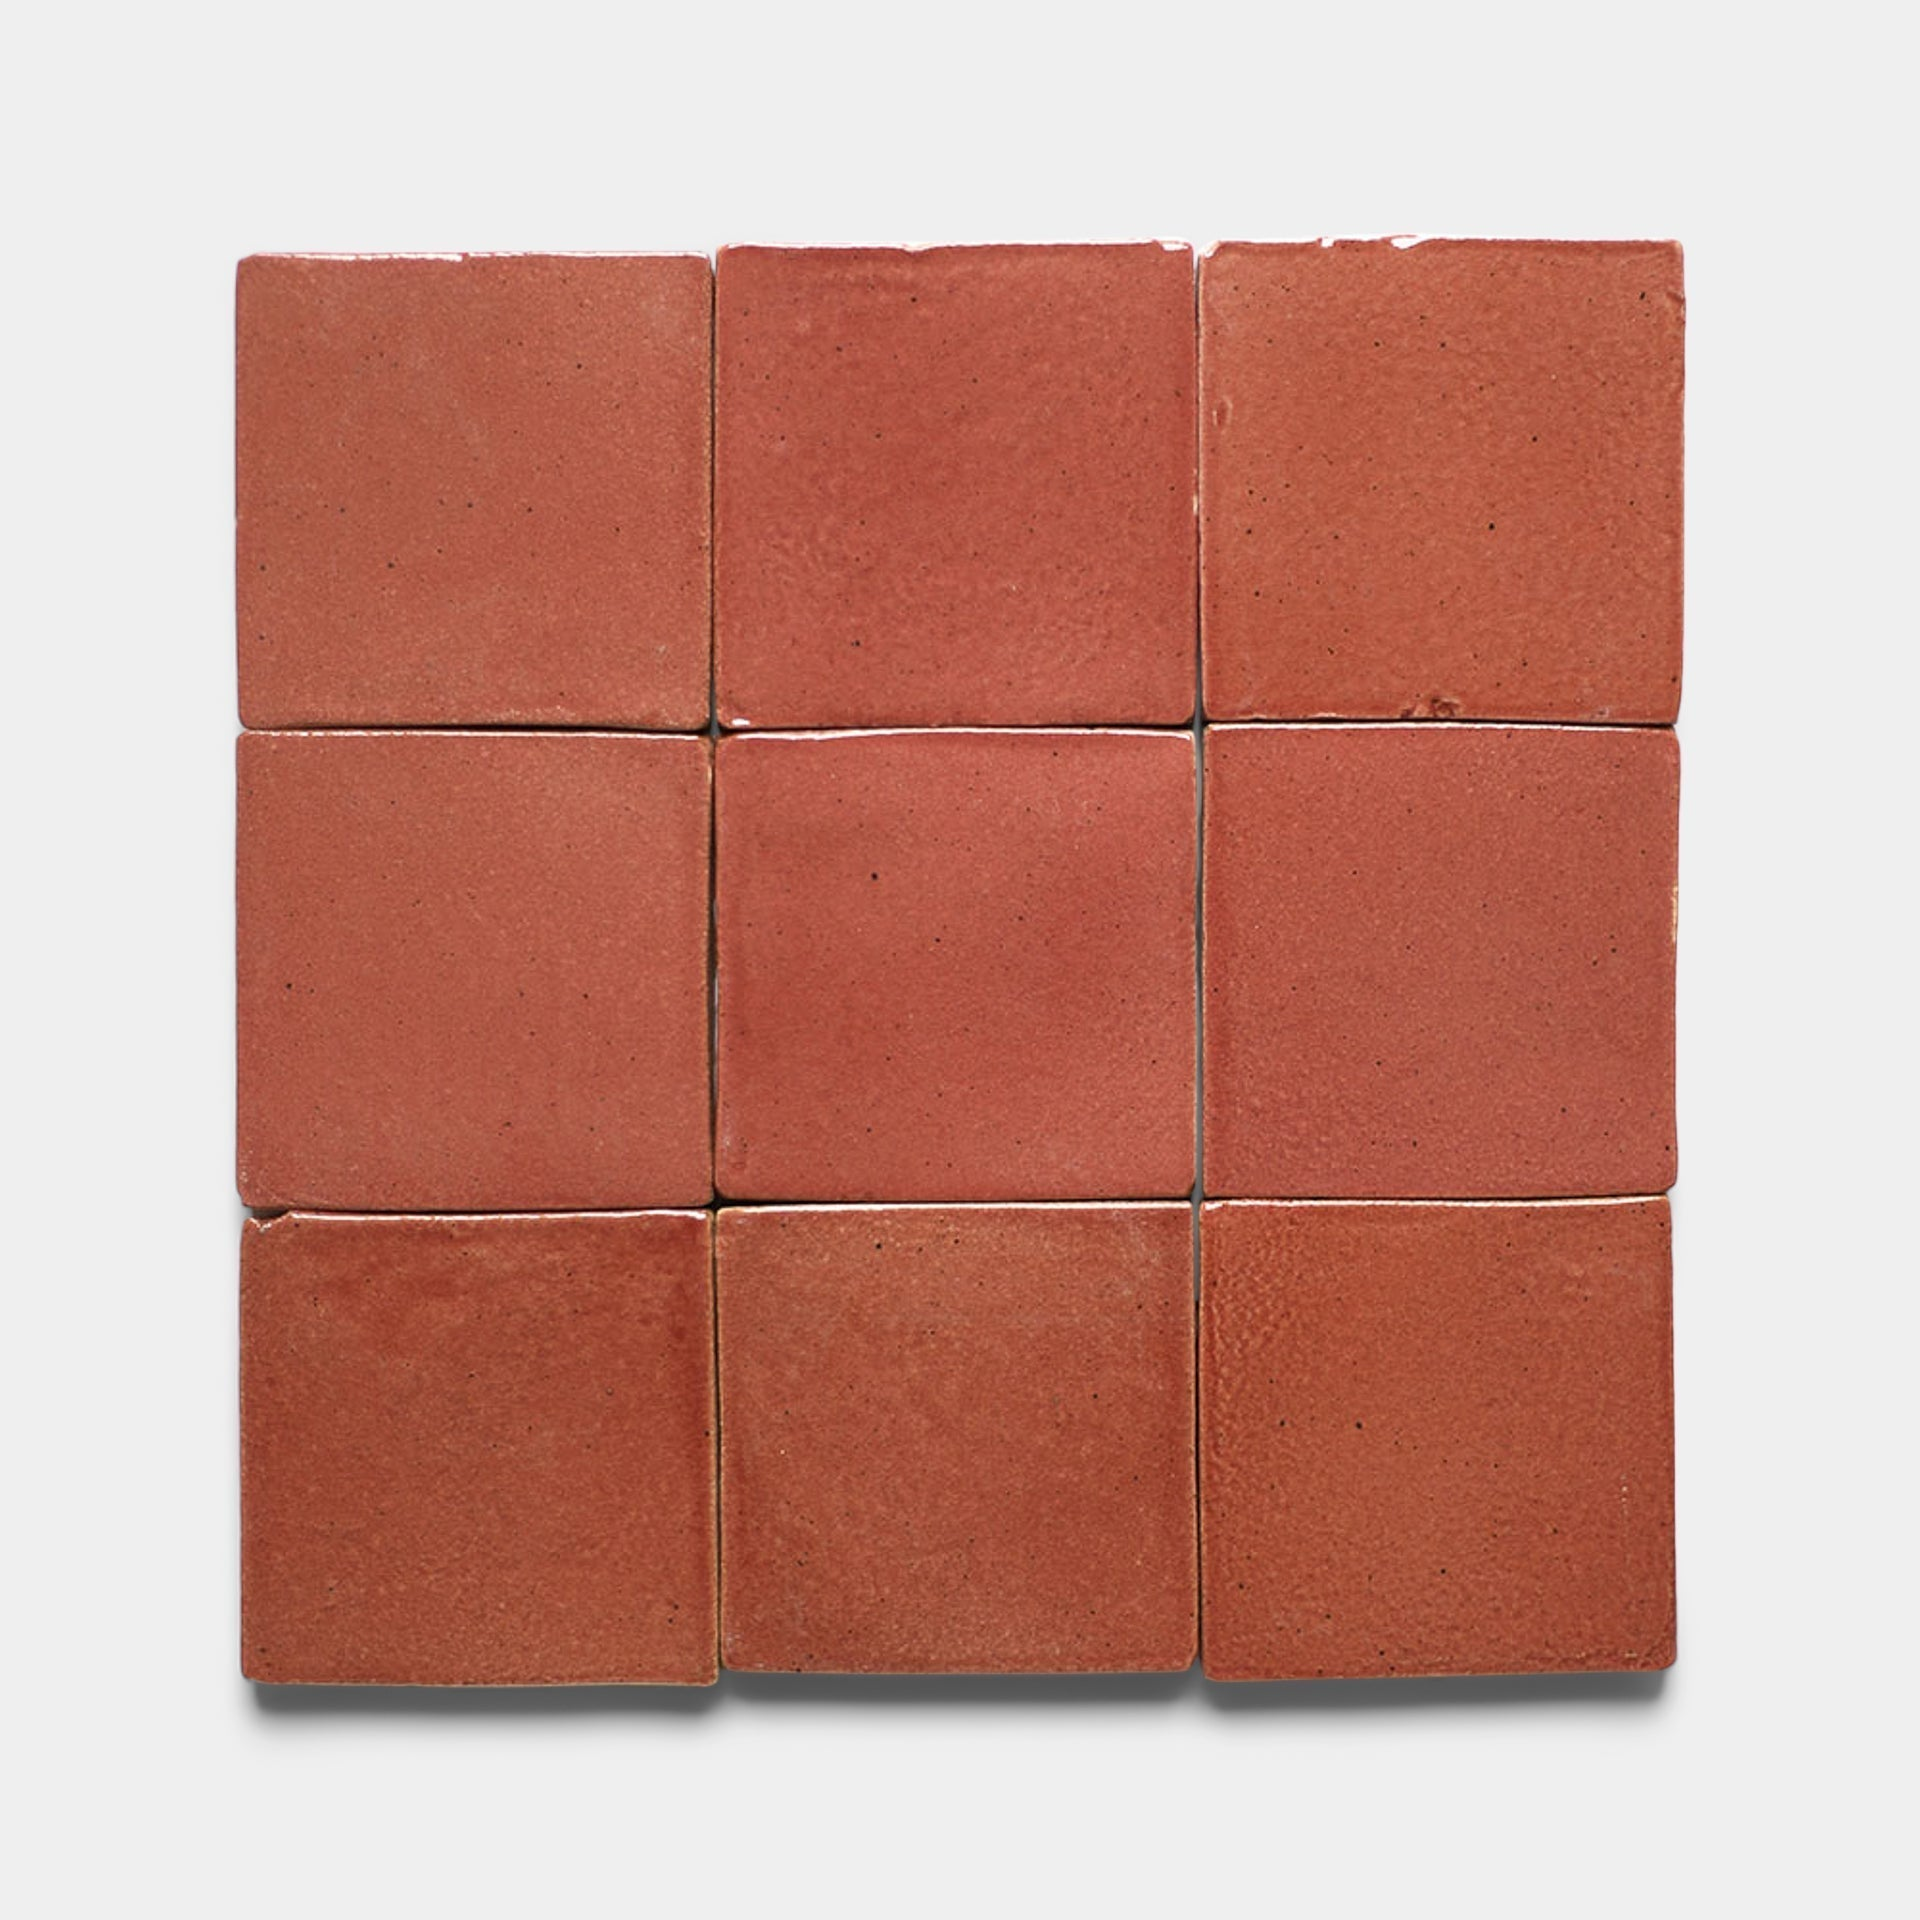

✅ Ceramic Tile


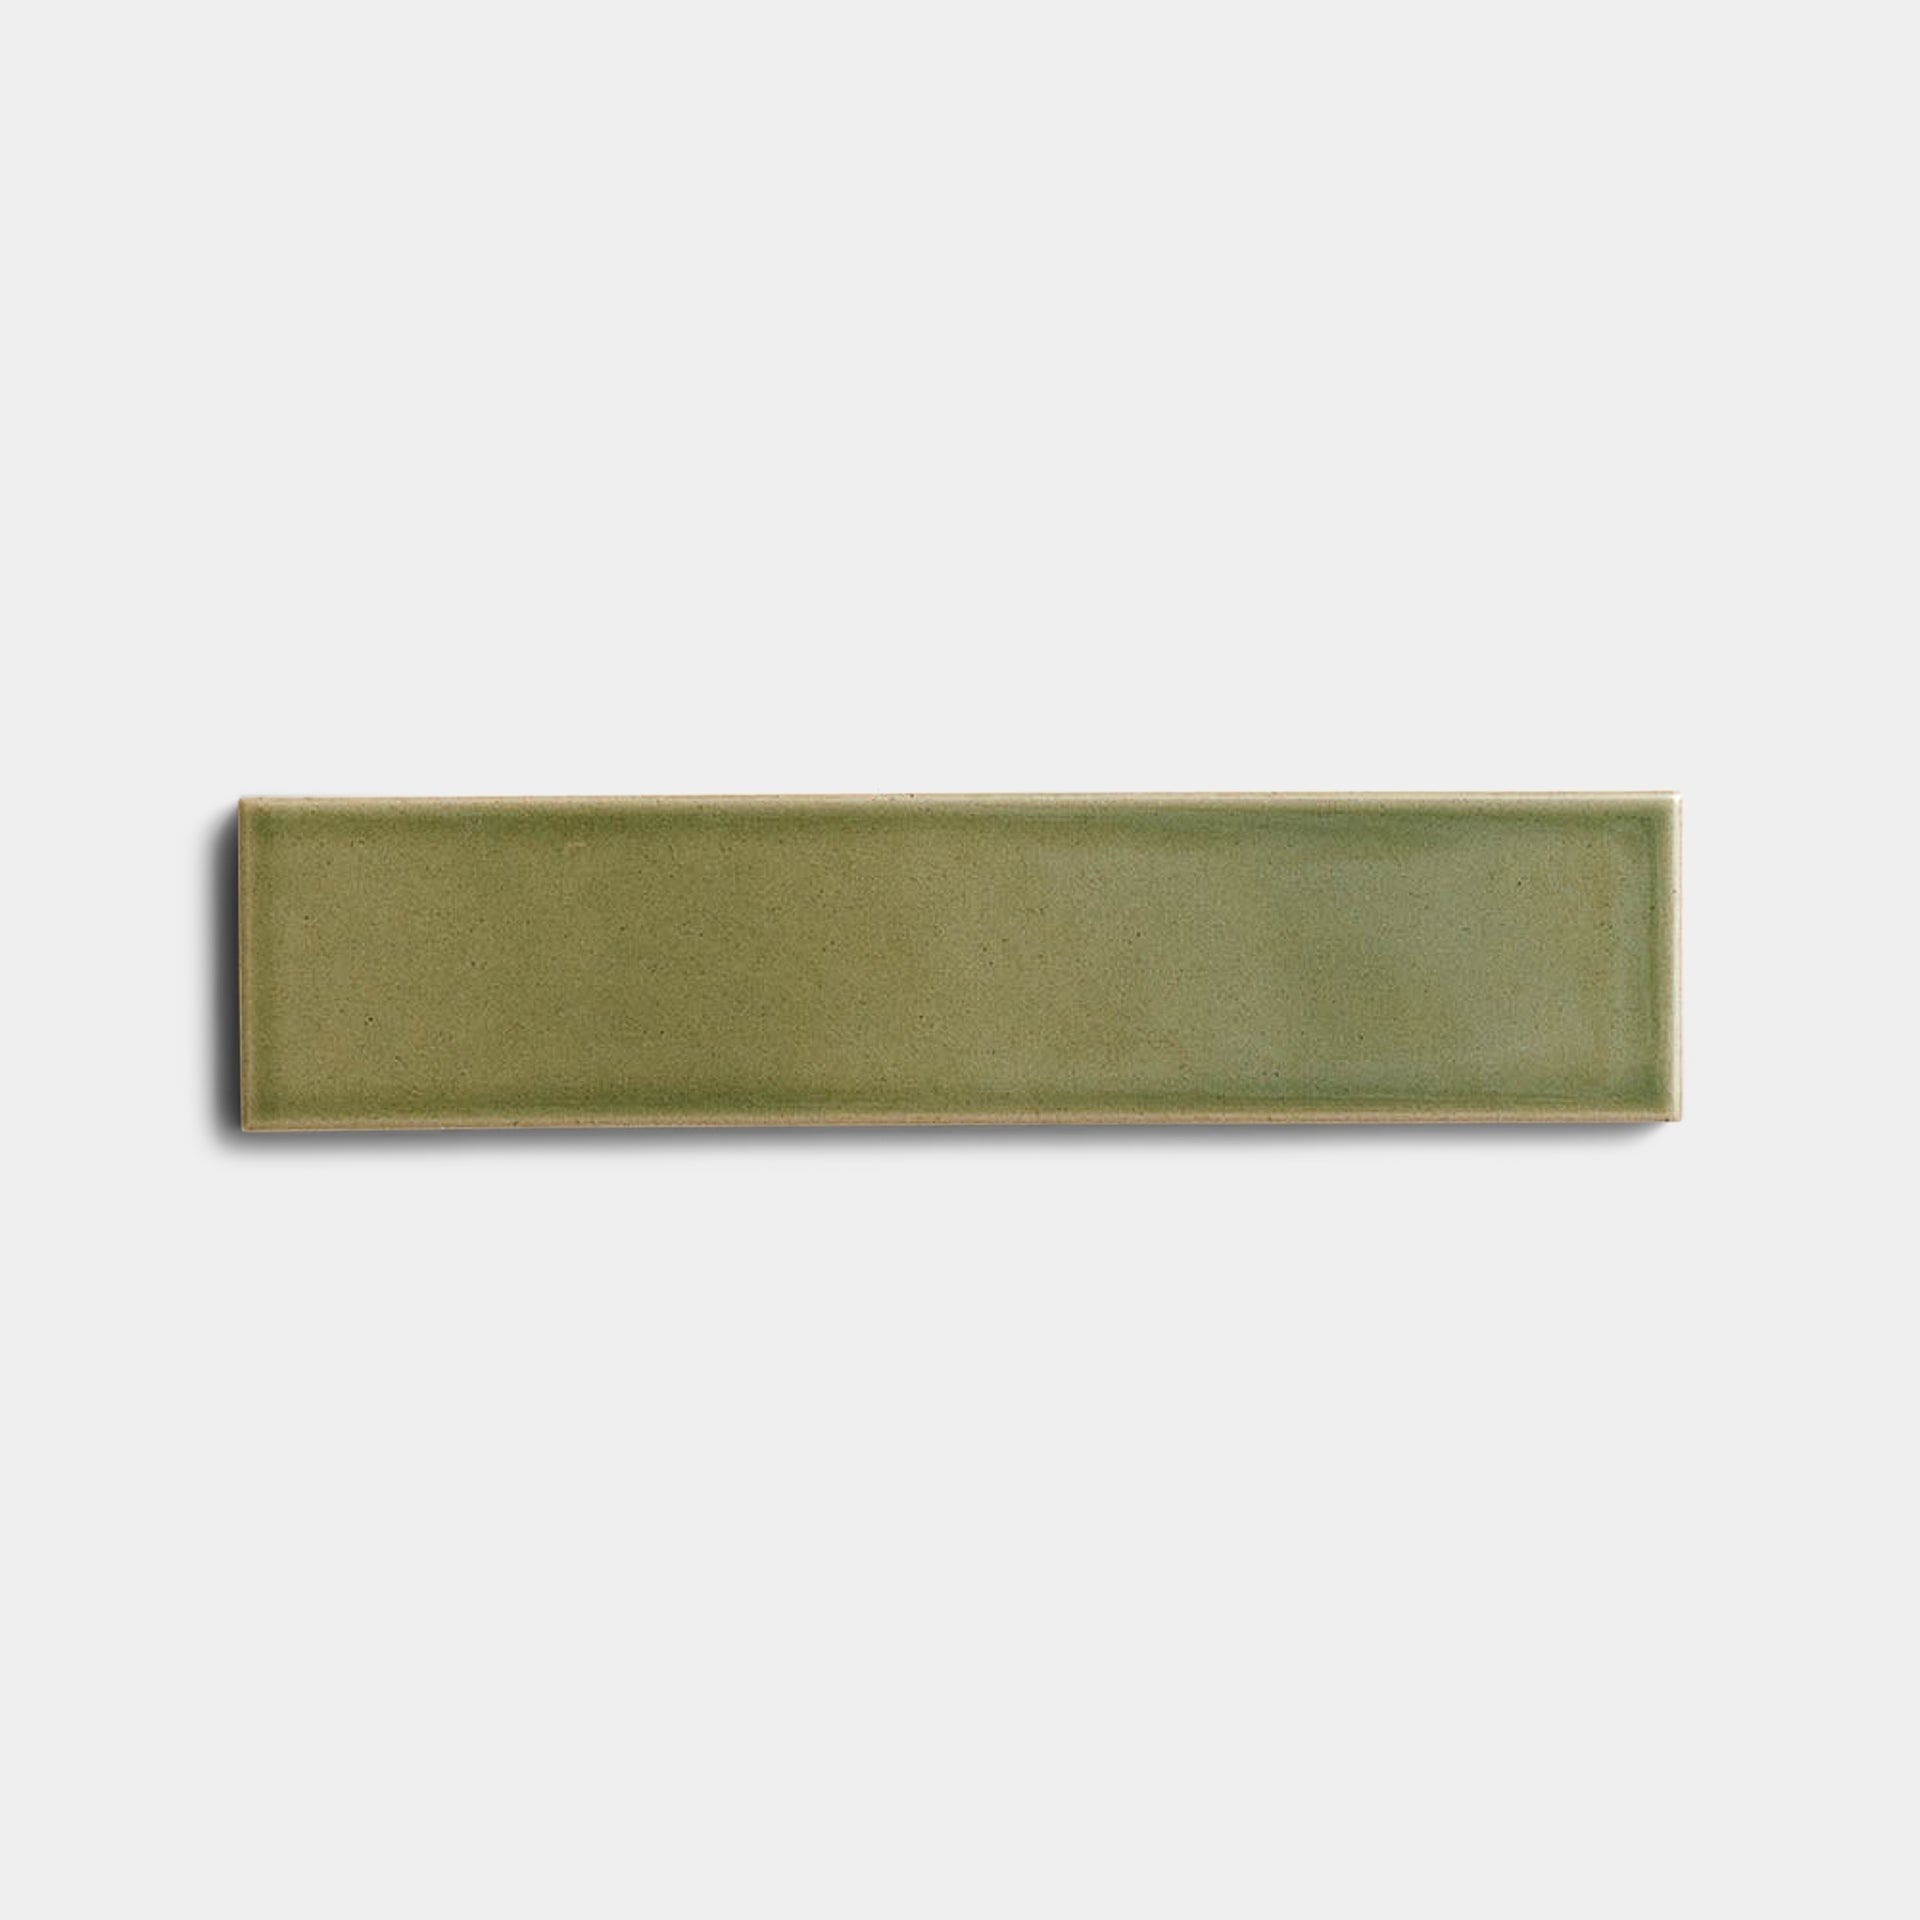

✅ Ceramic Tile


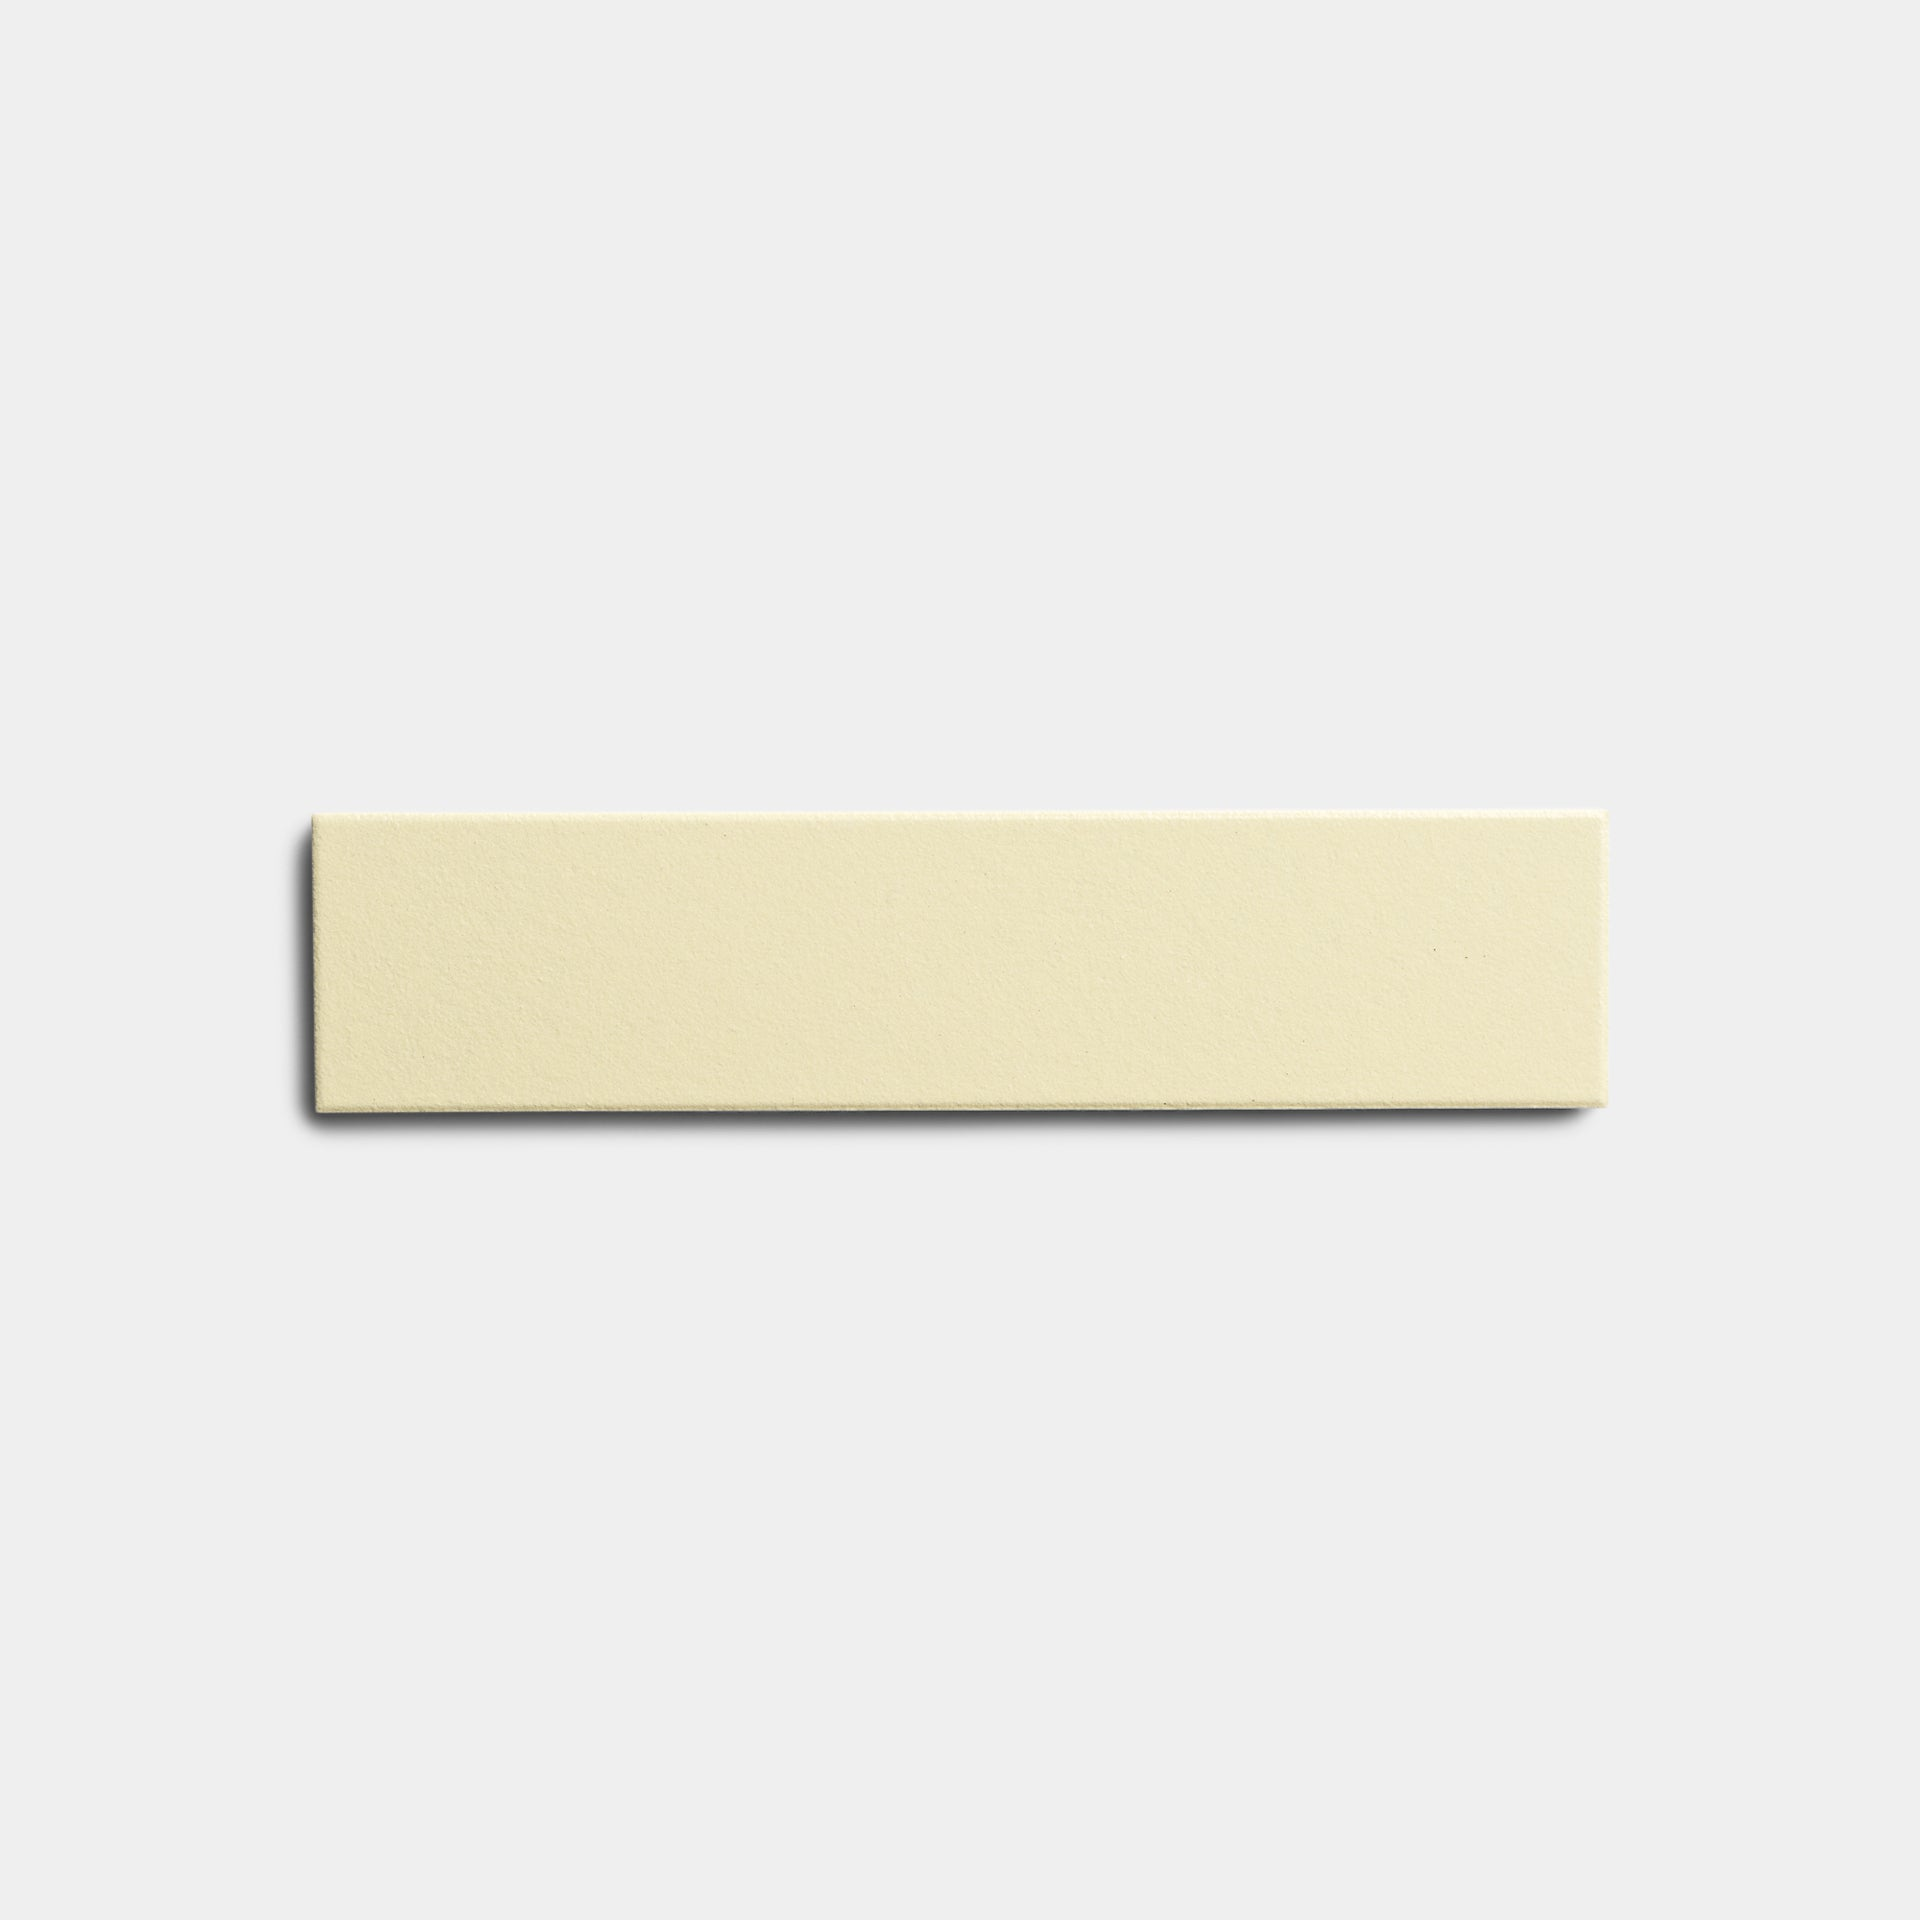

In [13]:
# Shopify 有内置 JSON API，直接返回产品数据包括图片
# URL 格式：https://ziatile.com/products/[product-handle].json

import requests
from IPython.display import Image, display
import os

os.makedirs('/content/images', exist_ok=True)

def get_shopify_image(product_url, material_name):
    try:
        # 从 URL 提取 product handle
        # https://ziatile.com/products/lupe-4x4 → lupe-4x4
        handle = product_url.rstrip('/').split('/products/')[-1].split('?')[0]
        domain = product_url.split('/products/')[0]

        # 调 Shopify JSON API
        api_url = f"{domain}/products/{handle}.json"
        r = requests.get(api_url, timeout=10)
        data = r.json()

        # 拿第一张图片
        images = data['product']['images']
        if images:
            img_url = images[0]['src'].split('?')[0]
            img_data = requests.get(img_url).content
            safe_name = material_name[:30].replace(' ','_').replace('/','_')
            filename = f"/content/images/{safe_name}.jpg"
            with open(filename, 'wb') as f:
                f.write(img_data)
            return filename, img_url
        return None, None

    except Exception as e:
        print(f"❌ {material_name}: {e}")
        return None, None

# 测试 Zia Tile
test_links = df[df['link'].str.contains('ziatile', na=False)][['name','link']].head(3)

for _, row in test_links.iterrows():
    path, url = get_shopify_image(row['link'], row['name'])
    if path:
        print(f"✅ {row['name']}")
        display(Image(path, width=250))
    else:
        print(f"❌ {row['name']}")

In [14]:
# Cell — 批量爬取所有有链接的材料图片 + 存回数据库

import sqlite3, requests, os, time
from IPython.display import Image, display

os.makedirs('/content/images', exist_ok=True)

def get_image_by_domain(url, material_name):
    """根据不同域名选择不同爬取策略"""
    try:
        # Shopify 商店（ziatile, tilebar, bairdbrothers 等）
        shopify_domains = ['ziatile.com', 'tilebar.com', 'bairdbrothers.com',
                          'borrowedearthcollaborative.com', 'ceilume.com']

        if any(d in url for d in shopify_domains):
            handle = url.rstrip('/').split('/products/')[-1].split('?')[0]
            domain = url.split('/products/')[0]
            api_url = f"{domain}/products/{handle}.json"
            r = requests.get(api_url, timeout=10)
            images = r.json()['product']['images']
            if images:
                return images[0]['src'].split('?')[0]

        # 其他网站：找 og:image（最通用的方法）
        else:
            headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'}
            r = requests.get(url, headers=headers, timeout=10)
            from bs4 import BeautifulSoup
            soup = BeautifulSoup(r.text, 'html.parser')
            og = soup.find('meta', property='og:image')
            if og:
                return og.get('content', '')

        return None
    except:
        return None

def download_image(img_url, material_name):
    try:
        safe_name = material_name[:40].replace(' ','_').replace('/','_')
        filename = f"/content/images/{safe_name}.jpg"
        img_data = requests.get(img_url, timeout=10).content
        with open(filename, 'wb') as f:
            f.write(img_data)
        return filename
    except:
        return None

# 获取所有有链接的材料
conn = sqlite3.connect('materials.db')
materials_with_links = pd.read_sql_query("""
    SELECT id, name, link FROM materials
    WHERE link IS NOT NULL
    AND link != ''
    AND link NOT LIKE '%amazon%'
""", conn)
conn.close()

print(f"准备爬取 {len(materials_with_links)} 条材料图片\n")

results = []
success = 0
failed = 0

for i, row in materials_with_links.iterrows():
    img_url = get_image_by_domain(row['link'], row['name'])

    if img_url:
        path = download_image(img_url, row['name'])
        if path:
            results.append({'id': row['id'], 'image_path': path})
            success += 1
            print(f"✅ [{success}] {row['name']}")
        else:
            failed += 1
    else:
        failed += 1
        print(f"❌ {row['name']}")

    time.sleep(0.5)  # 礼貌性延迟，不要太快

print(f"\n=== 完成 ===")
print(f"成功: {success} | 失败: {failed}")

# 把图片路径更新回数据库
conn = sqlite3.connect('materials.db')
# 先加 image_path 列
try:
    conn.execute("ALTER TABLE materials ADD COLUMN image_path TEXT")
    conn.commit()
except:
    pass  # 列已存在

for r in results:
    conn.execute("UPDATE materials SET image_path = ? WHERE id = ?",
                 (r['image_path'], r['id']))
conn.commit()
conn.close()

print(f"\n✅ 图片路径已更新进数据库")

准备爬取 80 条材料图片

✅ [1] Recessed
❌ Quarry Tile Cove Base
❌ Stool
✅ [2] Zellige Tile
❌ Troffer
❌ Track Head
Surface Mount
❌ Linear Pendant
✅ [3] Fabric
❌ Stone Slab
❌ Leather
❌ FRP Sheet
❌ Fluted Glass - Sneeze Guard
✅ [4] Antique Mirror
✅ [5] Acrylic Panel
❌ Reeded Effect Film
❌ Tin Ceiling Tile
❌ Paint
✅ [6] Concrete Tile
✅ [7] Concrete Tile
❌ Quarry Tile
❌ Quarry Tile
❌ Quarry Tile
✅ [8] Ceramic Tile
✅ [9] Ceramic Tile
✅ [10] Ceramic Tile
✅ [11] Ceramic Tile
❌ Molding
❌ Molding
❌ Molding
✅ [12] Zellige Tile
❌ Tin Ceiling Trim
❌ Plaster
✅ [13] Limewash Paint
❌ Plaster
✅ [14] Pendant
✅ [15] Wall Sconce
❌ New Exit Sign
✅ [16] CABINET DOOR PULL
❌ CURTAIN ROD
❌ CURTAIN ROD
❌ PIANO HINGE
✅ [17] LED
✅ [18] LED Channel
✅ [19] Ikea carcass
✅ [20] Ikea carcass
✅ [21] Ikea carcass
❌ Molding
✅ [22] Zellige Tile
✅ [23] Zellige Tile
✅ [24] Ceramic Tile
❌ Molding
✅ [25] CABINET DOOR PULL
❌ FRP Sheet @Oriol Grana Garriga to confirm if this can be replaced to melamine board / SS sheet
✅ [26] Zellige Til

## Phase 3

In [16]:
# Phase 3 — 安装依赖
!pip install fastapi uvicorn pyngrok nest-asyncio -q

print("✅ 安装完成")

✅ 安装完成


In [17]:
# 设置 ngrok token
from pyngrok import ngrok
ngrok.set_auth_token("3EdW9Ug0z6U75hDIGhlX0fKJsl8_3W4jcVCFEzjEUGTndkGq1")
print("✅ Token 设置完成")

✅ Token 设置完成


In [14]:
import nest_asyncio
import uvicorn
from fastapi import FastAPI, Query
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import JSONResponse
import sqlite3
import pandas as pd
from pyngrok import ngrok
import threading
import json

nest_asyncio.apply()

# 每次用随机端口避免冲突
import random
PORT = random.randint(8100, 8999)

app = FastAPI(title="Material Intelligence Engine", version="1.0")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

def get_db():
    conn = sqlite3.connect('/content/materials.db', check_same_thread=False)
    conn.row_factory = sqlite3.Row
    return conn

def safe_json(data):
    """彻底清除 NaN"""
    text = json.dumps(data, allow_nan=True)
    # 把 NaN/Infinity 直接替换成 null
    import re
    text = re.sub(r'\bNaN\b', 'null', text)
    text = re.sub(r'\bInfinity\b', 'null', text)
    text = re.sub(r'\b-Infinity\b', 'null', text)
    return json.loads(text)

@app.get("/")
def root():
    return {"status": "ok", "message": "Material Intelligence Engine is running"}

@app.get("/materials")
def get_materials(
    category: str = Query(None),
    manufacturer: str = Query(None),
    max_price: float = Query(None),
    min_price: float = Query(None),
    order_status: str = Query(None),
    project: str = Query(None),
    search: str = Query(None),
    limit: int = Query(50)
):
    conn = get_db()
    query = "SELECT id, name, category, manufacturer, unit_cost, order_status, project, image_path, link FROM materials WHERE 1=1"
    params = []

    if category:
        query += " AND category = ?"
        params.append(category)
    if manufacturer:
        query += " AND manufacturer LIKE ?"
        params.append(f"%{manufacturer}%")
    if max_price is not None:
        query += " AND unit_cost <= ?"
        params.append(max_price)
    if min_price is not None:
        query += " AND unit_cost >= ?"
        params.append(min_price)
    if order_status:
        query += " AND order_status = ?"
        params.append(order_status)
    if project:
        query += " AND project LIKE ?"
        params.append(f"%{project}%")
    if search:
        query += " AND (name LIKE ? OR description LIKE ? OR manufacturer LIKE ?)"
        params.extend([f"%{search}%"] * 3)

    query += f" LIMIT {limit}"
    df = pd.read_sql_query(query, conn, params=params)
    conn.close()
    records = df.where(pd.notnull(df), None).to_dict(orient='records')
    return JSONResponse(content=safe_json({"count": len(records), "materials": records}))

# 在 FastAPI cell 里加这个 endpoint（加在 @app.get("/categories") 前面）

@app.get("/search")
def semantic_search_endpoint(
    q: str = Query(..., description="自然语言搜索"),
    n: int = Query(5, description="返回数量")
):
    query_embedding = model.encode([q]).tolist()
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=n
    )

    matches = []
    for doc, meta, dist in zip(
        results['documents'][0],
        results['metadatas'][0],
        results['distances'][0]
    ):
        matches.append({
            "name": meta['name'],
            "category": meta['category'],
            "manufacturer": meta['manufacturer'],
            "db_id": meta['db_id'],
            "relevance_score": round(1 - dist, 4)
        })

    return JSONResponse(content=safe_json({
        "query": q,
        "count": len(matches),
        "results": matches
    }))
@app.get("/categories")
def get_categories():
    conn = get_db()
    df = pd.read_sql_query("""
        SELECT category, COUNT(*) as count
        FROM materials
        WHERE category IS NOT NULL
        GROUP BY category
        ORDER BY count DESC
    """, conn)
    conn.close()
    return JSONResponse(content=safe_json(df.to_dict(orient='records')))

@app.get("/materials/{material_id}")
def get_material(material_id: int):
    conn = get_db()
    df = pd.read_sql_query("SELECT * FROM materials WHERE id = ?", conn, params=[material_id])
    conn.close()
    if df.empty:
        return JSONResponse(content={"error": "Material not found"})
    records = df.where(pd.notnull(df), None).to_dict(orient='records')
    return JSONResponse(content=safe_json(records[0]))

# 启动
public_url = ngrok.connect(PORT)
print(f"✅ API running at: {public_url}")
print(f"📖 Docs: {public_url}/docs")
print(f"🔍 Materials: {public_url}/materials")
print(f"📂 Categories: {public_url}/categories")
print(f"🔌 Local port: {PORT}")

config = uvicorn.Config(app, host="0.0.0.0", port=PORT, log_level="error")
server = uvicorn.Server(config)
thread = threading.Thread(target=server.run, daemon=True)
thread.start()

✅ API running at: NgrokTunnel: "https://rubdown-imperial-faucet.ngrok-free.dev" -> "http://localhost:8390"
📖 Docs: NgrokTunnel: "https://rubdown-imperial-faucet.ngrok-free.dev" -> "http://localhost:8390"/docs
🔍 Materials: NgrokTunnel: "https://rubdown-imperial-faucet.ngrok-free.dev" -> "http://localhost:8390"/materials
📂 Categories: NgrokTunnel: "https://rubdown-imperial-faucet.ngrok-free.dev" -> "http://localhost:8390"/categories
🔌 Local port: 8390


In [16]:
import requests
r = requests.get(f"http://localhost:8462/materials", params={"category": "Finish"})
print("状态码:", r.status_code)
if r.status_code == 200:
    data = r.json()
    print(f"✅ 找到 {data['count']} 条材料")
    print(data['materials'][0])
else:
    print("错误:", r.text[:300])

状态码: 200
✅ 找到 34 条材料
{'id': 1, 'name': 'Quarry Tile Cove Base', 'category': 'Finish', 'manufacturer': 'Tilebar', 'unit_cost': 0.0, 'order_status': 'UPDATE PO', 'project': 'Alidoro ESB', 'image_path': None, 'link': 'https://www.tilebar.com/product/elemental-mayflower-red-ironspot-6x6-round-top-cove-base-sold-14pcs-per-box.html'}


## Phase 4

目标： 让用户可以用自然语言搜索，比如输入"防水瓷砖适合浴室"，系统能找到最相关的材料，即使数据库里没有这个关键词。

In [6]:
# Phase 4 — 安装 RAG 依赖
!pip install sentence-transformers chromadb -q

print("✅ 安装完成")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

In [7]:
# Phase 4 — 建立向量数据库
import sqlite3
import pandas as pd
import chromadb
from sentence_transformers import SentenceTransformer

# 1. 读取材料数据
conn = sqlite3.connect('/content/materials.db')
df = pd.read_sql_query("""
    SELECT id, name, category, manufacturer, description, finish_color, notes
    FROM materials
    WHERE name IS NOT NULL
""", conn)
conn.close()

print(f"准备向量化 {len(df)} 条材料...")

# 2. 把每条材料拼成一段文字
def build_text(row):
    parts = [
        row['name'] or '',
        row['category'] or '',
        row['manufacturer'] or '',
        row['finish_color'] or '',
        row['description'] or '',
        row['notes'] or '',
    ]
    return ' '.join([p for p in parts if p and str(p) != 'nan']).strip()

df['text'] = df.apply(build_text, axis=1)
print("文字样本：")
print(df['text'].head(3).to_string())

准备向量化 227 条材料...
文字样本：
0    Recessed Lighting Fixture Lusa New Constructio...
1    Quarry Tile Cove Base Finish Tilebar Ironspot ...
2    Stool Furniture Anthropologie Cocoa Pierre Tur...


In [9]:
# Phase 4 — 向量化 + 存入 ChromaDB

# 1. 加载模型
print("加载模型...")
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. 生成向量
print("生成向量...")
texts = df['text'].tolist()
embeddings = model.encode(texts, show_progress_bar=True)
print(f"✅ 生成了 {len(embeddings)} 个向量，维度: {embeddings.shape[1]}")

# 3. 存入 ChromaDB
print("存入 ChromaDB...")
chroma_client = chromadb.PersistentClient(path="/content/chroma_db")

# 如果已存在就删除重建
try:
    chroma_client.delete_collection("materials")
except:
    pass

collection = chroma_client.create_collection("materials")

# 用行号作为唯一 ID
collection.add(
    documents=texts,
    embeddings=embeddings.tolist(),
    ids=[str(i) for i in range(len(df))],
    metadatas=[{
        "name": str(row['name']),
        "category": str(row['category']) if row['category'] else "",
        "manufacturer": str(row['manufacturer']) if row['manufacturer'] else "",
        "db_id": str(row['id'])
    } for _, row in df.iterrows()]
)

print(f"✅ {collection.count()} 条材料已存入向量数据库")

加载模型...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


生成向量...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

✅ 生成了 227 个向量，维度: 384
存入 ChromaDB...
✅ 227 条材料已存入向量数据库


In [10]:
# Phase 4 — 测试语义搜索

def semantic_search(query, n_results=5):
    # 把查询文字也向量化
    query_embedding = model.encode([query]).tolist()

    # 在 ChromaDB 里找最相似的
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=n_results
    )

    print(f"\n🔍 查询: '{query}'")
    print(f"找到 {len(results['documents'][0])} 条相关材料：\n")

    for i, (doc, meta, dist) in enumerate(zip(
        results['documents'][0],
        results['metadatas'][0],
        results['distances'][0]
    )):
        similarity = 1 - dist
        print(f"{i+1}. {meta['name']} ({meta['category']})")
        print(f"   供应商: {meta['manufacturer']}")
        print(f"   相似度: {similarity:.2%}")
        print()

# 测试几个查询
semantic_search("bathroom floor tile waterproof")
semantic_search("pendant light for dining area")
semantic_search("wood finish warm tone")


🔍 查询: 'bathroom floor tile waterproof'
找到 5 条相关材料：

1. CEILING TILE American Tin Ceiling Pattern #2 Finish: UNFINISHED, Nail-Up, Non-Acoustic Size: 2'x2' ()
   供应商: 
   相似度: -28.93%

2. WALL BASE TILE IMPERIAL BIANCO GLOSS CERAMIC SUBWAY TILE 4"X8" ()
   供应商: 
   相似度: -29.18%

3. Ceramic Tile (Finish)
   供应商: Raid Tile
   相似度: -30.64%

4. FAUX BRICK TILE FLOOR & DECOR Avondale 2" x 8" Matte Brick Tile in Early Gray  800 SF ()
   供应商: 
   相似度: -31.32%

5. Mineral Fiber Tile (Finish)
   供应商: Armstrong
   相似度: -32.57%


🔍 查询: 'pendant light for dining area'
找到 5 条相关材料：

1. Pendant (Lighting Fixture)
   供应商: Ideas4Lighting
   相似度: 34.03%

2. Linear Pendant (Lighting Fixture)
   供应商: Etsy_
New Wine Old Bottles
   相似度: 23.56%

3. Custom Pendant (Lighting Fixture)
   供应商: Custom
   相似度: 13.73%

4. WAC LIGHTING Morae 44" Wide LED Abstract Linear Pendant Model:PD-33244-BN BRUSHED NICKEL 44" WIDTH ()
   供应商: 
   相似度: 12.05%

5. PENDANT LIGHT VISUAL CONFORT MODERN, MINI PONTE LED PENDANT LIGHT, 